In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline


In [2]:
years = range(1, 7)
months = ['H', 'M', 'U', 'Z']

contracts = [f'ES{m}{y}' for y in years for m in months]

start_contracts = 'ESZ1'
end_contracts = 'ESH6'

contracts = contracts[contracts.index(start_contracts):contracts.index(end_contracts)+1]

In [3]:
# prepare all the dataframe
fut_price = pd.read_excel('../data/processed/E-mini_expired_price.xlsx')
interest_rate = pd.read_excel('../data/processed/SOFR.xlsx')
dividend = pd.read_excel('../data/processed/spx_dividend.xlsx')
spx_price = pd.read_excel('../data/processed/spx_close.xlsx')

In [4]:
dfs = {
    'fut_price': fut_price,
    'interest_rate': interest_rate,
    'dividend': dividend[['Date', 'q']],
    'spx_close': spx_price
}

for name, df in dfs.items():
    df['Date'] = pd.to_datetime(df['Date'])
    dfs[name] = df.set_index('Date')

fut_price, interest_rate, dividend, spx_price = dfs.values()

In [5]:
analysis_df = pd.concat([fut_price, spx_price, interest_rate, dividend], axis=1, sort=True)
analysis_df = analysis_df.dropna(subset=['^SPX', '1M', '3M', '6M', '12M', 'q'])

In [6]:
analysis_df

,ESH1,ESM1,ESU1,ESZ1,ESH2,ESM2,ESU2,ESZ2,ESH3,ESM3,...,ESM5,ESU5,ESZ5,ESH6,^SPX,1M,3M,6M,12M,q
Date,,,,,,,,,,,,,,,,,,,,,
2021-09-21,NaN,NaN,NaN,4343.25,4335.75,4325.75,4321.25,4312.25,4303.50,4294.50,...,NaN,NaN,4289.50,NaN,4354.189941,0.000559,0.000594,0.000564,0.000607,0.016700
2021-09-22,NaN,NaN,NaN,4384.00,4376.50,4366.25,4360.50,4351.50,4342.50,4333.50,...,NaN,NaN,4328.50,NaN,4395.640137,0.000568,0.000580,0.000554,0.000595,0.016745
2021-09-23,NaN,NaN,NaN,4438.00,4430.50,4420.25,4412.75,4403.25,4393.75,4384.25,...,NaN,NaN,4379.00,NaN,4448.979980,0.000542,0.000569,0.000549,0.000608,0.016580
2021-09-24,NaN,NaN,NaN,4445.75,4438.25,4428.00,4419.00,4412.50,4403.75,4394.75,...,NaN,NaN,4401.75,NaN,4455.479980,0.000559,0.000579,0.000558,0.000654,0.016682
2021-09-27,NaN,NaN,NaN,4433.00,4425.50,4415.50,4408.50,4399.50,4390.75,4381.75,...,NaN,NaN,4388.75,NaN,4443.109863,0.000569,0.000583,0.000566,0.000689,0.017255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6594.63,6506.479980,0.036779,0.037062,0.037281,0.037564,0.012998
2026-03-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6581.000000,0.036785,0.037160,0.037517,0.038211,0.012860
2026-03-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6556.370117,0.036806,0.037109,0.037400,0.037813,0.012942


In [7]:
start_trade = {}
expiry = {}
for c in contracts:
    start_trade[c] = analysis_df[c].first_valid_index()
    expiry[c] = analysis_df[c].last_valid_index()

print("start_trade:", start_trade)
print("expiry:", expiry)

start_trade: {'ESZ1': Timestamp('2021-09-21 00:00:00'), 'ESH2': Timestamp('2021-09-21 00:00:00'), 'ESM2': Timestamp('2021-09-21 00:00:00'), 'ESU2': Timestamp('2021-09-21 00:00:00'), 'ESZ2': Timestamp('2021-09-21 00:00:00'), 'ESH3': Timestamp('2021-09-21 00:00:00'), 'ESM3': Timestamp('2021-09-21 00:00:00'), 'ESU3': Timestamp('2021-09-21 00:00:00'), 'ESZ3': Timestamp('2021-09-21 00:00:00'), 'ESH4': Timestamp('2021-12-15 00:00:00'), 'ESM4': Timestamp('2022-03-18 00:00:00'), 'ESU4': Timestamp('2022-06-16 00:00:00'), 'ESZ4': Timestamp('2021-09-21 00:00:00'), 'ESH5': Timestamp('2022-12-14 00:00:00'), 'ESM5': Timestamp('2023-03-16 00:00:00'), 'ESU5': Timestamp('2023-06-15 00:00:00'), 'ESZ5': Timestamp('2021-09-21 00:00:00'), 'ESH6': Timestamp('2023-08-17 00:00:00')}
expiry: {'ESZ1': Timestamp('2021-12-17 00:00:00'), 'ESH2': Timestamp('2022-03-18 00:00:00'), 'ESM2': Timestamp('2022-06-17 00:00:00'), 'ESU2': Timestamp('2022-09-16 00:00:00'), 'ESZ2': Timestamp('2022-12-16 00:00:00'), 'ESH3': Tim

In [8]:
for c in contracts:
    active = (
    (analysis_df.index >= start_trade[c]) &
    (analysis_df.index <= expiry[c])
)

    T_days = (expiry[c] - analysis_df.index).days
    # analysis_df[f'T_{c}_days'] = T_days.where(active)
    analysis_df[f'T_{c}'] = (T_days / 365).where(active)
analysis_df

,ESH1,ESM1,ESU1,ESZ1,ESH2,ESM2,ESU2,ESZ2,ESH3,ESM3,...,T_ESZ3,T_ESH4,T_ESM4,T_ESU4,T_ESZ4,T_ESH5,T_ESM5,T_ESU5,T_ESZ5,T_ESH6
Date,,,,,,,,,,,,,,,,,,,,,
2021-09-21,NaN,NaN,NaN,4343.25,4335.75,4325.75,4321.25,4312.25,4303.50,4294.50,...,2.232877,NaN,NaN,NaN,3.249315,NaN,NaN,NaN,4.246575,NaN
2021-09-22,NaN,NaN,NaN,4384.00,4376.50,4366.25,4360.50,4351.50,4342.50,4333.50,...,2.230137,NaN,NaN,NaN,3.246575,NaN,NaN,NaN,4.243836,NaN
2021-09-23,NaN,NaN,NaN,4438.00,4430.50,4420.25,4412.75,4403.25,4393.75,4384.25,...,2.227397,NaN,NaN,NaN,3.243836,NaN,NaN,NaN,4.241096,NaN
2021-09-24,NaN,NaN,NaN,4445.75,4438.25,4428.00,4419.00,4412.50,4403.75,4394.75,...,2.224658,NaN,NaN,NaN,3.241096,NaN,NaN,NaN,4.238356,NaN
2021-09-27,NaN,NaN,NaN,4433.00,4425.50,4415.50,4408.50,4399.50,4390.75,4381.75,...,2.216438,NaN,NaN,NaN,3.232877,NaN,NaN,NaN,4.230137,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2026-03-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


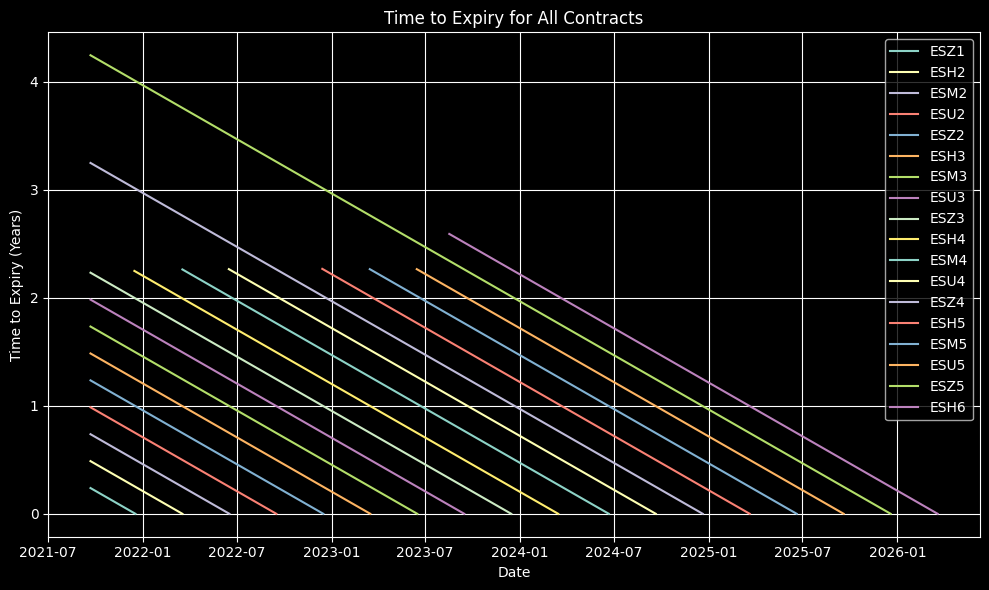

In [9]:
plt.figure(figsize=(10, 6))

for c in contracts:
    plt.plot(
        analysis_df.index,
        analysis_df[f'T_{c}'],
        label=c
    )

plt.xlabel("Date")
plt.ylabel("Time to Expiry (Years)")
plt.title("Time to Expiry for All Contracts")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
tenors = np.array([1/12, 3/12, 6/12, 1])

def interpolate_rate(row, T):
    if T == np.nan:
        return np.nan
    rates = np.array([row['1M'], row['3M'], row['6M'], row['12M']])
    cs = CubicSpline(tenors, rates, bc_type='natural')
    return cs(T).round(4)

In [11]:
# interpolation: risk-free rate
for c in contracts:
    analysis_df[f'r_{c}'] = analysis_df.apply(lambda row: interpolate_rate(row, row[f'T_{c}']), axis=1)

In [12]:
# fair value and basis
for c in contracts:
    analysis_df[f'Fair_{c}'] = analysis_df['^SPX'] * np.exp(
        (analysis_df[f'r_{c}'] - analysis_df['q'])
        * analysis_df[f'T_{c}']
    )
    # analysis_df[f'basis_{c}'] = analysis_df[c] - analysis_df[f'Fair_{c}']

In [13]:
analysis_df.to_csv('../data/processed/analysis_df.csv')

In [14]:
print(analysis_df.columns)

Index(['ESH1', 'ESM1', 'ESU1', 'ESZ1', 'ESH2', 'ESM2', 'ESU2', 'ESZ2', 'ESH3',
       'ESM3', 'ESU3', 'ESZ3', 'ESH4', 'ESM4', 'ESU4', 'ESZ4', 'ESH5', 'ESM5',
       'ESU5', 'ESZ5', 'ESH6', '^SPX', '1M', '3M', '6M', '12M', 'q', 'T_ESZ1',
       'T_ESH2', 'T_ESM2', 'T_ESU2', 'T_ESZ2', 'T_ESH3', 'T_ESM3', 'T_ESU3',
       'T_ESZ3', 'T_ESH4', 'T_ESM4', 'T_ESU4', 'T_ESZ4', 'T_ESH5', 'T_ESM5',
       'T_ESU5', 'T_ESZ5', 'T_ESH6', 'r_ESZ1', 'r_ESH2', 'r_ESM2', 'r_ESU2',
       'r_ESZ2', 'r_ESH3', 'r_ESM3', 'r_ESU3', 'r_ESZ3', 'r_ESH4', 'r_ESM4',
       'r_ESU4', 'r_ESZ4', 'r_ESH5', 'r_ESM5', 'r_ESU5', 'r_ESZ5', 'r_ESH6',
       'Fair_ESZ1', 'Fair_ESH2', 'Fair_ESM2', 'Fair_ESU2', 'Fair_ESZ2',
       'Fair_ESH3', 'Fair_ESM3', 'Fair_ESU3', 'Fair_ESZ3', 'Fair_ESH4',
       'Fair_ESM4', 'Fair_ESU4', 'Fair_ESZ4', 'Fair_ESH5', 'Fair_ESM5',
       'Fair_ESU5', 'Fair_ESZ5', 'Fair_ESH6'],
      dtype='str')


In [15]:
fields = ['PX', 'T', 'r', 'Fair', 'basis']
new_cols = []

for col in analysis_df.columns:
    if col.startswith('T_'):
        field = 'T'
        contract = col[2:]
    elif col.startswith('r_'):
        field = 'r'
        contract = col[2:]
    elif col.startswith('Fair_'):
        field = 'Fair'
        contract = col[5:]
    # elif col.startswith('basis_'):
    #     field = 'basis'
    #     contract = col[6:]
    else:
        # remaining contract columns are prices
        field = 'PX'
        contract = col
    new_cols.append((field, contract))

In [16]:
print(new_cols)

[('PX', 'ESH1'), ('PX', 'ESM1'), ('PX', 'ESU1'), ('PX', 'ESZ1'), ('PX', 'ESH2'), ('PX', 'ESM2'), ('PX', 'ESU2'), ('PX', 'ESZ2'), ('PX', 'ESH3'), ('PX', 'ESM3'), ('PX', 'ESU3'), ('PX', 'ESZ3'), ('PX', 'ESH4'), ('PX', 'ESM4'), ('PX', 'ESU4'), ('PX', 'ESZ4'), ('PX', 'ESH5'), ('PX', 'ESM5'), ('PX', 'ESU5'), ('PX', 'ESZ5'), ('PX', 'ESH6'), ('PX', '^SPX'), ('PX', '1M'), ('PX', '3M'), ('PX', '6M'), ('PX', '12M'), ('PX', 'q'), ('T', 'ESZ1'), ('T', 'ESH2'), ('T', 'ESM2'), ('T', 'ESU2'), ('T', 'ESZ2'), ('T', 'ESH3'), ('T', 'ESM3'), ('T', 'ESU3'), ('T', 'ESZ3'), ('T', 'ESH4'), ('T', 'ESM4'), ('T', 'ESU4'), ('T', 'ESZ4'), ('T', 'ESH5'), ('T', 'ESM5'), ('T', 'ESU5'), ('T', 'ESZ5'), ('T', 'ESH6'), ('r', 'ESZ1'), ('r', 'ESH2'), ('r', 'ESM2'), ('r', 'ESU2'), ('r', 'ESZ2'), ('r', 'ESH3'), ('r', 'ESM3'), ('r', 'ESU3'), ('r', 'ESZ3'), ('r', 'ESH4'), ('r', 'ESM4'), ('r', 'ESU4'), ('r', 'ESZ4'), ('r', 'ESH5'), ('r', 'ESM5'), ('r', 'ESU5'), ('r', 'ESZ5'), ('r', 'ESH6'), ('Fair', 'ESZ1'), ('Fair', 'ESH2'), (

In [17]:
analysis_multi = analysis_df.copy()
analysis_multi.columns = pd.MultiIndex.from_tuples(
    new_cols,
    names=['field', 'contract']
)
analysis_multi.to_csv('../data/processed/analysis_multi.csv')